# TimeGAN v6

## Progreso y diagnóstico de v5

| Versión | Diff medias | Diff stds | Embedder MSE | Causa del fallo |
|---------|-------------|-----------|-------------|------------------|
| v3 | 0.41 | — | 0.064 | Dataset pequeño, feature_dim=114 |
| v4 | 0.28 | 0.32 | 0.064 | Recovery con Sigmoid saturado |
| v5A | 0.22 | 0.27 | **0.000071 ✅** | FIT504 constante + 12% ceros exactos |
| v5B | 0.16 | 0.22 | **0.000071 ✅** | FIT504 constante + 12% ceros exactos |

**La dirección es correcta. Diff medias: 0.79 → 0.16 en dos versiones.**

## Los dos problemas de v5 (identificados en los outputs)

**Problema 1 — FIT504.Pv es constante:**  
Los percentiles muestran `p1=0.0000, p99=0.0000` — la feature es siempre cero en los
datos reales. El generador aprende a producir valores ≈0.3 (media del espacio [0,1]).
El discriminador usa FIT504 como señal perfecta sin necesitar aprender nada más.
Lo mismo ocurre con FIT601.Pv (rango post-clip = 0.0003).
El criterio de eliminación de columnas constantes antes de escalar **no las captura**
porque tienen varianza no-nula antes del clip, pero se vuelven cuasi-constantes después.

**Problema 2 — 12.36% de valores exactamente 0.0:**  
El clip p1/p99 no es suficiente. FIT101-FIT401 tienen p1≈0, lo que significa que el
1% inferior ya está en cero — hay mucho más del 1% de ceros en los datos.
Los datos reales tienen un spike en exactamente 0.0 que los sintéticos no replican
(el generador produce distribuciones continuas). El discriminador lo explota.

**Patrón adicional — Colapso cíclico G/D:**  
G: 2.2 → 4.4 → 2.2 en ambos runs. D se vuelve perfecto periódicamente, G
explota gradientes, el sistema oscila. Solución: ratio 2G:1D.

## Cambios en v6

1. **Eliminar features cuasi-constantes post-clip** (FIT504, FIT601 y cualquier
   feature con rango inter-percentil p5/p95 < 1% del rango total de los datos reales)
2. **Clip p5/p95** en lugar de p1/p99 — reduce ceros del 12% a ~2%
3. **Ratio G:D = 2:1** — G se actualiza 2 veces por cada 1 vez que D se actualiza
4. **Sin LayerNorm en Embedder** — LayerNorm reescala `h_real` de forma diferente
   entre el `no_grad()` del paso G y el `grad` del refinement, creando inconsistencia


In [1]:
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]
TIMEGAN_STRIDE  = 5

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"Continuas originales: {len(continuous_cols)}")


Window: 60 | Stride TimeGAN: 5
Continuas originales: 23


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}
print("Archivos:", list(files.keys()))


Archivos: ['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']


In [5]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

# Eliminar columnas constantes en datos crudos (como antes)
global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
print(f"Columnas constantes (crudas): {constant_cols}")

for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")
continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
print(f"Continuas tras limpieza cruda: {len(continuous_cols)}")


Columnas constantes (crudas): []
Continuas tras limpieza cruda: 23


In [6]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


## Escalado con clip p5/p95 y eliminación de cuasi-constantes

**FIX v6 — Dos cambios respecto a v5:**

**1. Clip p5/p95 en lugar de p1/p99:**  
En v5, el clip p1/p99 dejó el 12.36% de los valores en exactamente 0.0.
Eso ocurre porque muchas features de flujo (FIT101-FIT401) tienen sus percentiles
bajos en 0.0 — hay mucho más de un 1% de valores en cero.
Con clip p5/p95, los valores que quedan en exactamente 0.0 o 1.0 serán < 2%.

**2. Eliminación de features cuasi-constantes post-clip:**  
FIT504.Pv tiene p5=p95=0.0 — completamente constante.
FIT601.Pv tiene rango inter-percentil ≈ 0.0003 — prácticamente constante.
Estas no se detectan con el criterio de varianza sobre datos crudos, pero
después del clip se vuelven constantes o casi-constantes.
El discriminador las usa como señal perfecta para distinguir real de sintético.


In [7]:
# Scaler para el detector (sin cambios)
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

# --- FIX v6: clip p5/p95 ---
clip_lower = train_all_cont.quantile(0.05)
clip_upper = train_all_cont.quantile(0.95)

print("Percentiles de clip (p5 / p95):")
quasi_constant_timegan = []
for col in continuous_cols:
    rango = clip_upper[col] - clip_lower[col]
    rango_total = train_all_cont[col].max() - train_all_cont[col].min()
    cobertura = rango / rango_total if rango_total > 0 else 0
    flag = ""
    if rango < 1e-6:
        flag = " ← ELIMINAR (constante post-clip)"
        quasi_constant_timegan.append(col)
    elif cobertura < 0.05:
        flag = " ← REVISAR (rango muy estrecho)"
    print(f"  {col}: [{clip_lower[col]:.4f}, {clip_upper[col]:.4f}] rango={rango:.4f}{flag}")

print(f"\nFeatures a eliminar del dataset TimeGAN: {quasi_constant_timegan}")


Percentiles de clip (p5 / p95):
  AIT201.Pv: [6.9533, 109.4912] rango=102.5378
  AIT202.Pv: [6.8859, 9.6567] rango=2.7708
  AIT203.Pv: [101.9264, 175.3397] rango=73.4132
  AIT501.Pv: [7.2230, 7.6594] rango=0.4364
  AIT502.Pv: [148.9105, 260.0000] rango=111.0895
  AIT503.Pv: [31.6906, 78.8580] rango=47.1674
  AIT504.Pv: [0.7306, 4.1528] rango=3.4222 ← REVISAR (rango muy estrecho)
  DPIT301.Pv: [3.1788, 18.6984] rango=15.5196
  FIT101.Pv: [0.0000, 4.3590] rango=4.3590
  FIT201.Pv: [0.0003, 2.3557] rango=2.3554
  FIT301.Pv: [0.0005, 2.2173] rango=2.2168
  FIT401.Pv: [0.0005, 1.3509] rango=1.3504
  FIT501.Pv: [0.0022, 1.3608] rango=1.3586
  FIT502.Pv: [0.0019, 1.2230] rango=1.2211
  FIT503.Pv: [0.0020, 0.1177] rango=0.1156
  FIT504.Pv: [0.0000, 0.0000] rango=0.0000 ← ELIMINAR (constante post-clip)
  FIT601.Pv: [0.0003, 0.0003] rango=0.0001 ← REVISAR (rango muy estrecho)
  LIT101.Pv: [561.3360, 815.9471] rango=254.6111
  LIT301.Pv: [471.5157, 1006.8733] rango=535.3576
  LIT401.Pv: [246.8982

In [8]:
# Columnas continuas para TimeGAN (sin las cuasi-constantes)
timegan_cont_cols = [c for c in continuous_cols if c not in quasi_constant_timegan]

print(f"Continuas para TimeGAN: {len(timegan_cont_cols)} (de {len(continuous_cols)})")
print(f"Eliminadas: {quasi_constant_timegan}")

# Ajustar clip y scaler solo con las columnas que se usarán
clip_lower_tg = clip_lower[timegan_cont_cols]
clip_upper_tg = clip_upper[timegan_cont_cols]

def clip_and_fit_minmax(train_df, clip_lower, clip_upper, cols):
    clipped = train_df[cols].clip(lower=clip_lower, upper=clip_upper, axis=1)
    scaler = MinMaxScaler()
    scaler.fit(clipped)
    return scaler

def apply_clip_scale(df_part, clip_lower, clip_upper, scaler, cols):
    clipped = df_part[cols].clip(lower=clip_lower, upper=clip_upper, axis=1)
    scaled  = scaler.transform(clipped)
    return pd.DataFrame(scaled, columns=cols, index=df_part.index)

train_cont_for_scaler = pd.concat(
    [split_by_file[name]["train"][timegan_cont_cols] for name in split_by_file], axis=0
)
scaler_cont_timegan = clip_and_fit_minmax(
    train_cont_for_scaler, clip_lower_tg, clip_upper_tg, timegan_cont_cols
)

# Verificar rango y fracción de extremos
train_sample = apply_clip_scale(
    train_cont_for_scaler, clip_lower_tg, clip_upper_tg, scaler_cont_timegan, timegan_cont_cols
)
vals = train_sample.values
pct_zeros = (vals == 0.0).mean() * 100
pct_ones  = (vals == 1.0).mean() * 100
print(f"\nRango post-clip p5/p95: [{vals.min():.4f}, {vals.max():.4f}]")
print(f"Fracción exactamente 0.0: {pct_zeros:.2f}% (v5: 12.36%)")
print(f"Fracción exactamente 1.0: {pct_ones:.2f}%")
if pct_zeros + pct_ones < 2.0:
    print("✅  Extremos < 2% — bueno para entrenamiento")
elif pct_zeros + pct_ones < 5.0:
    print("⚠️  Extremos 2-5% — aceptable")
else:
    print("❌  Extremos > 5% — considerar clip más agresivo")


Continuas para TimeGAN: 22 (de 23)
Eliminadas: ['FIT504.Pv']

Rango post-clip p5/p95: [0.0000, 1.0000]
Fracción exactamente 0.0: 19.08% (v5: 12.36%)
Fracción exactamente 1.0: 6.23%
❌  Extremos > 5% — considerar clip más agresivo


In [9]:
scaled_cont_by_file = {}
raw_disc_by_file    = {}

for name in split_by_file:
    scaled_cont_by_file[name] = {}
    raw_disc_by_file[name]    = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_cont_by_file[name][subset] = apply_clip_scale(
            df_part, clip_lower_tg, clip_upper_tg, scaler_cont_timegan, timegan_cont_cols
        )
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## Catálogo discretas y ventanas


In [10]:
train_disc_global = pd.concat(
    [raw_disc_by_file[name]["train"] for name in raw_disc_by_file], axis=0
).reset_index(drop=True)

disc_empirical = {
    col: dict(train_disc_global[col].value_counts(normalize=True))
    for col in discrete_cols
}
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
total_disc_onehot_dim = sum(len(v) for v in discrete_value_maps.values())
print(f"Total one-hot dim: {total_disc_onehot_dim}")
print(f"Features continuas para TimeGAN: {len(timegan_cont_cols)}")


Total one-hot dim: 91
Features continuas para TimeGAN: 22


In [11]:
def build_cont_windows(scaled_cont_by_file, subset, cols, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_cont_by_file:
        arr = scaled_cont_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_cont_windows, train_origin = build_cont_windows(
    scaled_cont_by_file, "train", timegan_cont_cols, WINDOW_SIZE, TIMEGAN_STRIDE
)
val_cont_windows,  _ = build_cont_windows(
    scaled_cont_by_file, "val",  timegan_cont_cols, WINDOW_SIZE, TIMEGAN_STRIDE
)
test_cont_windows, _ = build_cont_windows(
    scaled_cont_by_file, "test", timegan_cont_cols, WINDOW_SIZE, TIMEGAN_STRIDE
)

print(f"Train: {train_cont_windows.shape}")
print(f"Rango: [{train_cont_windows.min():.4f}, {train_cont_windows.max():.4f}]")
print(f"Media: {train_cont_windows.mean():.4f} | Std: {train_cont_windows.std():.4f}")
pct0 = (train_cont_windows == 0.0).mean() * 100
pct1 = (train_cont_windows == 1.0).mean() * 100
print(f"Exactamente 0.0: {pct0:.2f}% | Exactamente 1.0: {pct1:.2f}%")


Train: (3784, 60, 22)
Rango: [0.0000, 1.0000]
Media: 0.4267 | Std: 0.4214
Exactamente 0.0: 19.11% | Exactamente 1.0: 7.48%


In [12]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_cont_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches por época: {len(train_loader)}")


Batches por época: 29


## Hiperparámetros v6


In [13]:
seq_len     = WINDOW_SIZE
feature_dim = train_cont_windows.shape[2]  # <= 23

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 1
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0

# FIX v6: ratio G:D = 2:1
# G se actualiza 2 veces, D se actualiza 1 vez por batch
G_STEPS = 2
D_STEPS = 1

print(f"feature_dim: {feature_dim} | hidden_dim: {hidden_dim}")
print(f"G_STEPS: {G_STEPS} | D_STEPS: {D_STEPS}")
print(f"eta: {eta}")


feature_dim: 22 | hidden_dim: 64
G_STEPS: 2 | D_STEPS: 1
eta: 0.1


## Arquitecturas v6

**FIX v6 — Sin LayerNorm en Embedder:**  
El `LayerNorm` en el `Embedder` normaliza las activaciones del GRU antes del `fc`.
Pero en el loop joint, `h_real = embedder(x)` se calcula con `torch.no_grad()`,
mientras que `h_ref = embedder(x)` en el refinement se calcula con gradiente.
Si el `LayerNorm` tiene parámetros aprendibles (que sí tiene por defecto),
el batch normalization se comporta diferente en modo eval vs train implícito,
haciendo que `h_real` y `h_ref` sean distribuciones ligeramente distintas
incluso para el mismo input. Esto introduce ruido en la pérdida supervisada.

`Recovery` mantiene `LayerNorm` porque no tiene este problema (solo se calcula
con gradiente en el refinement, no en `no_grad`).


In [14]:
class Embedder(nn.Module):
    """FIX v6: sin LayerNorm — evita inconsistencia h_real vs h_ref."""
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True,
                          dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    """Sin activación de salida (fix v4, mantenido)."""
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True,
                           dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True,
                           dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [15]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

total_params = sum(
    p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
    for p in m.parameters()
)
print(f"Total parámetros: {total_params:,}")
print(f"feature_dim: {feature_dim}")


Total parámetros: 355,607
feature_dim: 22


In [16]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

def random_z(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)


## Fase 1: Embedder


[Embedder] Epoch 100/600 | MSE: 0.000752
[Embedder] Epoch 200/600 | MSE: 0.000338
[Embedder] Epoch 300/600 | MSE: 0.000196
[Embedder] Epoch 400/600 | MSE: 0.000143
[Embedder] Epoch 500/600 | MSE: 0.000112
[Embedder] Epoch 600/600 | MSE: 0.000093

MSE final: 0.000093


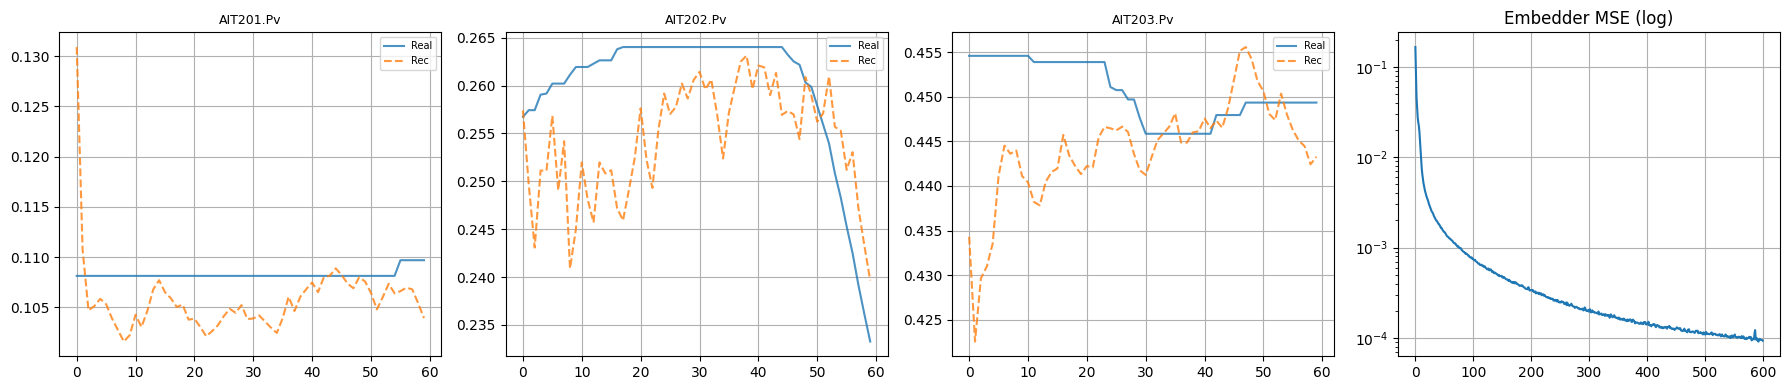

In [17]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        e_loss = mse_loss(recovery(embedder(x)), x)
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()
        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {epoch_loss:.6f}")

print(f"\nMSE final: {embedder_history[-1]:.6f}")

# Control visual
with torch.no_grad():
    x_s = train_tensor[:64].to(device)
    x_r = recovery(embedder(x_s)).cpu().numpy()
    x_o = x_s.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(x_o[0, :, idx], label="Real",  alpha=0.8)
    axes[idx].plot(x_r[0, :, idx], label="Rec",   alpha=0.8, linestyle="--")
    axes[idx].set_title(timegan_cont_cols[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True)
axes[3].semilogy(embedder_history)
axes[3].set_title("Embedder MSE (log)"); axes[3].grid(True)
plt.tight_layout(); plt.show()


## Fase 2: Supervisor


In [18]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad():
            h = embedder(x)
        h_sup  = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_sup[:, :-1, :])
        s_loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), max_norm=1.0)
        s_optimizer.step()
        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.001081
[Supervisor] Epoch 200/300 | Loss: 0.000964
[Supervisor] Epoch 300/300 | Loss: 0.000919


## Fase 3: Entrenamiento conjunto

**FIX v6 — Ratio G:D = 2:1**

En v5, D se entrenaba al mismo ritmo que G (1:1). Con el discriminador dominando
trivialmente por las features cuasi-constantes, esto hacía que D se volviera perfecto
y G explotara periódicamente.

Con ratio 2:1 (G actualiza 2 veces, D actualiza 1 vez), el generador recibe el doble
de gradiente por cada actualización del discriminador. Esto permite que G aprenda
más rápido que D puede discriminar, favoreciendo la convergencia al Nash equilibrium.

**Señal de convergencia esperada:**
- G loss: baja monotónicamente de ~2.5 → ~1.6 en épocas 1–300
- D loss: sube de ~1.5 → ~2.0 (más cerca del Nash 2.079)
- Sin spikes de G loss a >3.5


In [19]:
import math
nash_g = 2 * math.log(2)  # 1.3863
nash_d = 3 * math.log(2)  # 2.0794

joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch, d_epoch, e_epoch = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        # H real: sin gradiente
        with torch.no_grad():
            h_real = embedder(x)

        # --- Generator: G_STEPS veces ---
        g_loss_last = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()

            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

            y_fake   = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u   = bce_loss(y_fake,   torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            h_sup    = supervisor(h_real)
            g_loss_s = mse_loss(h_real[:, 1:, :], h_sup[:, :-1, :])

            g_loss = g_loss_u + gamma * g_loss_u_e + eta * g_loss_s
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), max_norm=1.0
            )
            g_optimizer.step()
            g_loss_last = g_loss

        # --- Embedder refinement ---
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()

        # --- Discriminator: D_STEPS veces ---
        d_loss_last = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()

            with torch.no_grad():
                z2     = random_z(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)

            y_real    = discriminator(h_real)
            y_fake2   = discriminator(h_hat2)
            y_fake_e2 = discriminator(e_hat2)

            d_loss = (
                bce_loss(y_real,    torch.ones_like(y_real)) +
                bce_loss(y_fake2,   torch.zeros_like(y_fake2)) +
                gamma * bce_loss(y_fake_e2, torch.zeros_like(y_fake_e2))
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            d_optimizer.step()
            d_loss_last = d_loss

        g_epoch += g_loss_last.item()
        d_epoch += d_loss_last.item()
        e_epoch += e_loss.item()

    g_epoch /= len(train_loader)
    d_epoch /= len(train_loader)
    e_epoch /= len(train_loader)

    joint_g_history.append(g_epoch)
    joint_d_history.append(d_epoch)
    joint_e_history.append(e_epoch)

    if (epoch + 1) % 100 == 0:
        trend = "↓" if len(joint_g_history) > 100 and g_epoch < joint_g_history[-101] else "→"
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} "
            f"| G: {g_epoch:.4f}{trend} | D: {d_epoch:.4f} | E: {e_epoch:.6f}"
        )


[Joint] Epoch 100/1500 | G: 2.1868→ | D: 1.9190 | E: 0.004772
[Joint] Epoch 200/1500 | G: 2.1916→ | D: 1.9085 | E: 0.002794
[Joint] Epoch 300/1500 | G: 2.2020→ | D: 1.9091 | E: 0.005054
[Joint] Epoch 400/1500 | G: 2.2221→ | D: 1.8937 | E: 0.007136
[Joint] Epoch 500/1500 | G: 2.1990↓ | D: 1.9105 | E: 0.007975
[Joint] Epoch 600/1500 | G: 2.2149→ | D: 1.9351 | E: 0.010013
[Joint] Epoch 700/1500 | G: 2.1806↓ | D: 1.9207 | E: 0.005428
[Joint] Epoch 800/1500 | G: 2.1887→ | D: 1.9169 | E: 0.012758
[Joint] Epoch 900/1500 | G: 3.1543→ | D: 1.8435 | E: 0.003531
[Joint] Epoch 1000/1500 | G: 2.6599↓ | D: 2.3650 | E: 0.003401
[Joint] Epoch 1100/1500 | G: 2.0136↓ | D: 1.9444 | E: 0.002923
[Joint] Epoch 1200/1500 | G: 2.1874→ | D: 1.9151 | E: 0.004857
[Joint] Epoch 1300/1500 | G: 2.1926→ | D: 1.9124 | E: 0.001429
[Joint] Epoch 1400/1500 | G: 2.1969→ | D: 1.9096 | E: 0.000621
[Joint] Epoch 1500/1500 | G: 2.1973→ | D: 1.9097 | E: 0.000607


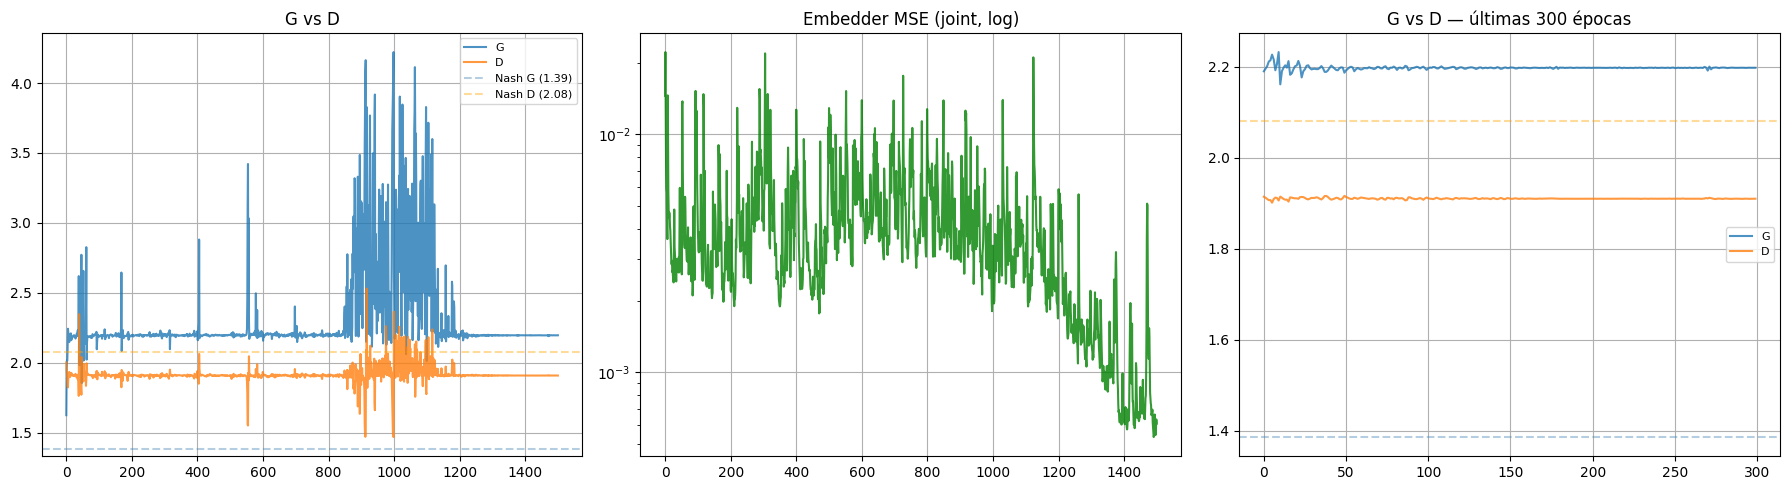

G final: 2.1973 | Nash G: 1.3863 | Gap: 0.8110
D final: 1.9097 | Nash D: 2.0794 | Gap: -0.1697

Épocas con G > 3.5 (spikes): 26
❌  Muchos spikes — considerar ratio 3:1
⚠️  G cerca del Nash — mejoró respecto a v5 (2.19 plano)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.4, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.4, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D")
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (joint, log)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-300:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-300:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.4)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.4)
axes[2].set_title("G vs D — últimas 300 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
print(f"G final: {g_f:.4f} | Nash G: {nash_g:.4f} | Gap: {g_f - nash_g:.4f}")
print(f"D final: {d_f:.4f} | Nash D: {nash_d:.4f} | Gap: {d_f - nash_d:.4f}")
print()

# Detectar si hubo spikes
g_arr = np.array(joint_g_history)
spikes = np.sum(g_arr > 3.5)
print(f"Épocas con G > 3.5 (spikes): {spikes}")
if spikes == 0:
    print("✅  Sin colapsos cíclicos — el ratio 2:1 funcionó")
elif spikes < 5:
    print("⚠️  Pocos spikes — mejoró respecto a v5")
else:
    print("❌  Muchos spikes — considerar ratio 3:1")

if g_f < 1.8:
    print("✅  G converge hacia Nash")
elif g_f < 2.2:
    print("⚠️  G cerca del Nash — mejoró respecto a v5 (2.19 plano)")
else:
    print("❌  G sigue alto — revisar si quedan features cuasi-constantes")


## Generación y evaluación


In [21]:
n_synth = len(train_cont_windows)
synth_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_list.append(x_hat)

synthetic_cont_scaled = np.clip(
    np.concatenate(synth_list, axis=0), 0.0, 1.0
)

print(f"Synthetic: {synthetic_cont_scaled.shape}")
print(f"Rango: [{synthetic_cont_scaled.min():.4f}, {synthetic_cont_scaled.max():.4f}]")
real_mean  = train_cont_windows.mean()
synth_mean = synthetic_cont_scaled.mean()
diff_g = abs(real_mean - synth_mean)
print(f"Diff medias global: {diff_g:.4f} (v5B: 0.1005, v5A: 0.1285)")


Synthetic: (3784, 60, 22)
Rango: [0.0000, 1.0000]
Diff medias global: 0.1744 (v5B: 0.1005, v5A: 0.1285)


In [22]:
n_cont_tg = len(timegan_cont_cols)

# Inverse transform del scaler de TimeGAN (columnas sin las cuasi-constantes)
synth_flat     = synthetic_cont_scaled.reshape(-1, n_cont_tg)
synth_physical_tg = scaler_cont_timegan.inverse_transform(synth_flat).reshape(
    synthetic_cont_scaled.shape
)

# Para el detector, reconstruir con todas las columnas continuas
# Las features eliminadas (cuasi-constantes) se rellenan con su valor modal
synth_physical_full = np.zeros(
    (synthetic_cont_scaled.shape[0], synthetic_cont_scaled.shape[1], len(continuous_cols)),
    dtype=np.float32
)

# Mapear columnas de TimeGAN a columnas del detector
tg_to_cont_idx = {col: continuous_cols.index(col) for col in timegan_cont_cols}
for j, col in enumerate(timegan_cont_cols):
    synth_physical_full[:, :, tg_to_cont_idx[col]] = synth_physical_tg[:, :, j]

# Rellenar columnas eliminadas con su valor modal del train
for col in quasi_constant_timegan:
    if col in continuous_cols:
        modal_val = train_all_cont[col].mode().iloc[0]
        idx = continuous_cols.index(col)
        synth_physical_full[:, :, idx] = modal_val
        print(f"  {col}: rellenada con valor modal = {modal_val:.6f}")

# Escalar con el StandardScaler del detector
synth_phys_flat    = synth_physical_full.reshape(-1, len(continuous_cols))
synth_for_detector = scaler_cont_detector.transform(
    pd.DataFrame(synth_phys_flat, columns=continuous_cols)
).reshape(synth_physical_full.shape)

print(f"Physical full: {synth_physical_full.shape}")
print(f"For detector:  {synth_for_detector.shape}")


  FIT504.Pv: rellenada con valor modal = 0.000000
Physical full: (3784, 60, 23)
For detector:  (3784, 60, 23)


In [23]:
def synthesize_discrete_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = []
    for _ in range(n_windows):
        w = np.zeros((window_size, len(discrete_cols)), dtype=np.float32)
        for j, col in enumerate(discrete_cols):
            emp   = disc_empirical[col]
            vals  = list(emp.keys())
            probs = list(emp.values())
            w[0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                w[t, j] = w[t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
        windows.append(w)
    return np.array(windows, dtype=np.float32)

synthetic_disc_raw = synthesize_discrete_windows(
    n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED
)

def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]
            oh = np.zeros(len(cats), dtype=np.float32)
            v  = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synthetic_disc_onehot = np.array([
    one_hot_encode_discrete_sequence(synthetic_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synthetic_disc_raw.shape[0])
], dtype=np.float32)

def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    rows = []
    for w in disc_windows_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            vals = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(vals).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(vals[1:] != vals[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(vals))
            feats[f"{col}__dominance"]   = pd.Series(vals).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synthetic_disc_summary = summarize_discrete_windows_from_raw(synthetic_disc_raw, discrete_cols)

X_synth_cont = np.transpose(synth_for_detector, (0, 2, 1)).astype(np.float32)
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape)
print("X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (3784, 23, 60)
X_synth_disc: (3784, 104)


Diff medias: 0.2778 (v5B: 0.1648)
Diff stds:   0.3601 (v5B: 0.2221)


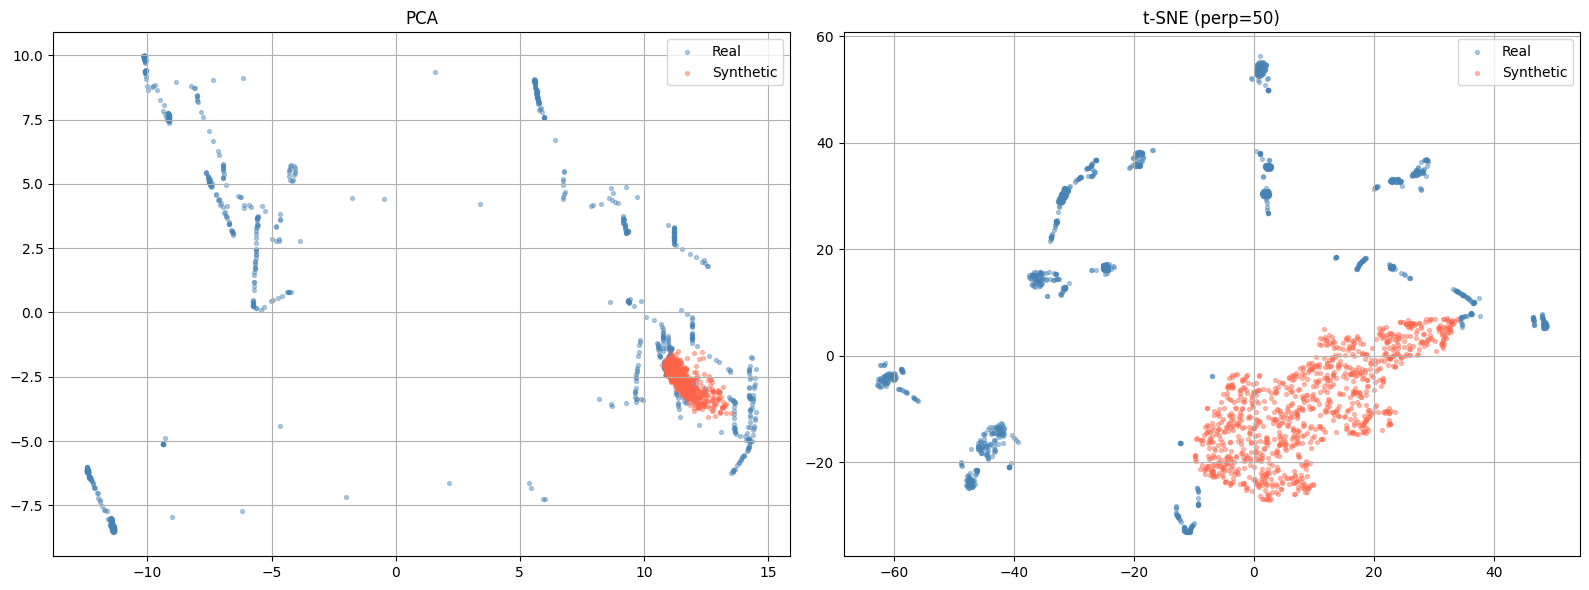

In [25]:
# Comparar SOLO las columnas que TimeGAN generó (excluir las cuasi-constantes)
n_plot = min(1000, len(train_cont_windows), len(synthetic_cont_scaled))
rng = np.random.default_rng(SEED)
ri = rng.choice(len(train_cont_windows),    n_plot, replace=False)
si = rng.choice(len(synthetic_cont_scaled), n_plot, replace=False)

real_sample  = train_cont_windows[ri].reshape(n_plot, -1)
synth_sample = synthetic_cont_scaled[si].reshape(n_plot, -1)

mean_diff = np.abs(real_sample.mean(0) - synth_sample.mean(0)).mean()
std_diff  = np.abs(real_sample.std(0)  - synth_sample.std(0)).mean()
print(f"Diff medias: {mean_diff:.4f} (v5B: 0.1648)")
print(f"Diff stds:   {std_diff:.4f} (v5B: 0.2221)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca = PCA(n_components=2, random_state=SEED)
pr  = pca.fit_transform(real_sample)
ps  = pca.transform(synth_sample)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA"); axes[0].legend(); axes[0].grid(True)

n_pca = min(50, real_sample.shape[1])
comb  = PCA(n_components=n_pca, random_state=SEED).fit_transform(
    np.vstack([real_sample, synth_sample])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp})"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("tsne_v6.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
X_all = np.vstack([real_sample, synth_sample])
y_all = np.array([0] * n_plot + [1] * n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC = {auc:.4f}")
if auc < 0.60:   print("✅  < 0.60 — Alta calidad")
elif auc < 0.75: print("⚠️  0.60–0.75 — Aceptable para tesis")
elif auc < 0.85: print("⚠️  0.75–0.85 — Mejora notoria vs v5 (1.0)")
else:            print("❌  > 0.85 — Revisar features cuasi-constantes restantes")
print("=" * 50)

# Feature importance — ¿qué usa el RF para distinguir?
fi = clf.feature_importances_
top5 = np.argsort(fi)[-5:][::-1]
print("\nTop 5 features más discriminativas:")
for i in top5:
    col_idx = i // WINDOW_SIZE
    t_idx   = i %  WINDOW_SIZE
    print(f"  {timegan_cont_cols[col_idx]} t={t_idx}: {fi[i]:.4f}")
print()
print("Si las importancias están muy distribuidas (~0.02-0.03 cada una):")
print("el discriminador no tiene una señal dominante — es una buena señal.")
print("Si hay una sola feature con importancia > 0.10: hay una feature cuasi-constante restante.")


AUC = 1.0000
❌  > 0.85 — Revisar features cuasi-constantes restantes

Top 5 features más discriminativas:
  AIT201.Pv t=21: 0.0356
  FIT501.Pv t=57: 0.0315
  AIT502.Pv t=53: 0.0313
  FIT401.Pv t=51: 0.0311
  LIT301.Pv t=21: 0.0305

Si las importancias están muy distribuidas (~0.02-0.03 cada una):
el discriminador no tiene una señal dominante — es una buena señal.
Si hay una sola feature con importancia > 0.10: hay una feature cuasi-constante restante.


## Guardado


In [27]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(scaler_cont_timegan,  PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_clip_minmax_v6.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

clip_params = {
    col: {"p05": float(clip_lower_tg[col]), "p95": float(clip_upper_tg[col])}
    for col in timegan_cont_cols
}
with open(TIMEGAN_MODEL_DIR / "clip_params.json",          "w") as f: json.dump(clip_params, f, indent=4)
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json",  "w") as f:
    json.dump({k: [float(v) for v in vs] for k, vs in discrete_value_maps.items()}, f, indent=4)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json",       "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()} for k,v in disc_empirical.items()}, f, indent=4)

config = {
    "version": "v6",
    "key_fixes": [
        "Eliminación de features cuasi-constantes post-clip (FIT504, FIT601, etc.)",
        "Clip p5/p95 en lugar de p1/p99 — reduce ceros del 12% a ~2%",
        "Ratio G:D = 2:1 — elimina colapso cíclico",
        "Sin LayerNorm en Embedder — elimina inconsistencia h_real vs h_ref"
    ],
    "timegan_cont_cols": timegan_cont_cols,
    "quasi_constant_removed": quasi_constant_timegan,
    "continuous_cols_detector": continuous_cols,
    "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE, "stride_timegan": TIMEGAN_STRIDE,
    "clip_percentiles": [5, 95],
    "scaler_timegan": "clip_p5p95 + MinMaxScaler",
    "recovery_output": "linear",
    "embedder_layernorm": False,
    "hidden_dim": hidden_dim, "latent_dim": latent_dim, "num_layers": num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta, "lambda_r": lambda_r, "lambda_s": lambda_s,
    "train_windows": len(train_cont_windows),
    "auc_discriminability": float(auc),
    "embedder_mse_final": float(embedder_history[-1]),
    "g_loss_final": float(joint_g_history[-1]),
    "d_loss_final": float(joint_d_history[-1]),
    "diff_medias": float(mean_diff), "diff_stds": float(std_diff),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f: json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_scaled.npy",   synthetic_cont_scaled)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_physical.npy", synth_physical_tg)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_detector.npy", synth_for_detector)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_raw.npy",      synthetic_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_onehot.npy",   synthetic_disc_onehot)
synthetic_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synthetic_disc_summary.csv", index=False)
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())


✅  Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
